## Importación de Librerías

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import resample_poly

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)


NumPy: 2.3.5
Pandas: 3.0.3
TensorFlow: 2.21.0


## Carga y validación de los datos crudos

Se buscan todos los CSV en `../Data/Raw Data`, se valida que solo existan los dos esquemas conocidos, y se separan
los vuelos que siguen el esquema "estándar" (`time`, `baro_altitude`, `accl_x/y/z`, ...) del reporte suelto que
tiene otras columnas (`t`, `h`, `P`, ...).


In [2]:
DATA_PATH = Path("../Data/Raw Data")

files = sorted(DATA_PATH.glob("*.csv"))
print(f"Archivos encontrados: {len(files)}")
for f in files:
    print(" -", f.name)


Archivos encontrados: 63
 - 10_standardized.csv
 - 11_standardized.csv
 - 12_standardized.csv
 - 13_standardized.csv
 - 14_standardized.csv
 - 15_standardized.csv
 - 16_standardized.csv
 - 17_standardized.csv
 - 18_standardized.csv
 - 19_standardized.csv
 - 1_standardized.csv
 - 20_standardized.csv
 - 21_standardized.csv
 - 22_standardized.csv
 - 23_standardized.csv
 - 24_standardized.csv
 - 25_standardized.csv
 - 26_standardized.csv
 - 27_standardized.csv
 - 28_standardized.csv
 - 29_standardized.csv
 - 2_standardized.csv
 - 30_standardized.csv
 - 31_standardized.csv
 - 32_standardized.csv
 - 33_standardized.csv
 - 34_standardized.csv
 - 35_standardized.csv
 - 36_standardized.csv
 - 37_standardized.csv
 - 38_standardized.csv
 - 39_standardized.csv
 - 3_standardized.csv
 - 4_standardized.csv
 - 5_standardized.csv
 - 6_standardized.csv
 - 7_standardized.csv
 - 8_standardized.csv
 - 9_standardized.csv
 - altus1_standardized.csv
 - altus2_standardized.csv
 - altus3_standardized.csv
 - alt

In [3]:
# Validación de esquemas: todos los archivos deben tener una de dos estructuras conocidas
schemas = {f.name: list(pd.read_csv(f, nrows=0).columns) for f in files}
unique_schemas = set(tuple(cols) for cols in schemas.values())
print(f"Número de estructuras diferentes: {len(unique_schemas)}")
for i, schema in enumerate(unique_schemas, start=1):
    print(f"\nEstructura {i}:")
    for col in schema:
        print("  -", col)


Número de estructuras diferentes: 2

Estructura 1:
  - t
  - h
  - P
  - T
  - ρ
  - a
  - Vx
  - Ax
  - Ay
  - Az
  - At

Estructura 2:
  - time
  - baro_altitude
  - accl_x
  - accl_y
  - accl_z
  - gps_altitude
  - gyro_roll
  - gyro_pitch
  - gyro_yaw


In [4]:
STRUCTURE_1_COLS = {"t", "h", "P", "T", "ρ", "a", "Vx", "Ax", "Ay", "Az", "At"}
STRUCTURE_2_COLS = {
    "time", "baro_altitude", "accl_x", "accl_y", "accl_z",
    "gps_altitude", "gyro_roll", "gyro_pitch", "gyro_yaw",
}

structure_1_files, structure_2_files = [], []
for f in files:
    cols = set(schemas[f.name])
    if STRUCTURE_1_COLS.issubset(cols):
        structure_1_files.append(f)
    elif STRUCTURE_2_COLS.issubset(cols):
        structure_2_files.append(f)

print("Estructura 1 (reporte suelto):", len(structure_1_files))
print("Estructura 2 (vuelos estandarizados):", len(structure_2_files))


Estructura 1 (reporte suelto): 1
Estructura 2 (vuelos estandarizados): 62


In [5]:
# Frecuencia de muestreo de cada vuelo estandarizado
sampling_summary = []
for file in structure_2_files:
    df = pd.read_csv(file)
    dt = df["time"].diff()
    sampling_summary.append({
        "flight": file.stem,
        "samples": len(df),
        "duration_s": df["time"].iloc[-1] - df["time"].iloc[0],
        "dt_mean": dt.mean(),
        "dt_std": dt.std(),
        "frequency_hz": 1 / dt.mean(),
        "missing_values": df.isna().sum().sum(),
    })

sampling_summary = pd.DataFrame(sampling_summary)
display(sampling_summary)
print("\nResumen de frecuencia (Hz):")
print(sampling_summary["frequency_hz"].describe())


,flight,samples,duration_s,dt_mean,dt_std,frequency_hz,missing_values
0,10_standardized,3229,64.561,0.020000,1.760083e-05,49.999226,0
1,11_standardized,816,16.300,0.020000,8.055274e-16,50.000000,0
2,12_standardized,2568,51.341,0.020000,1.973727e-05,49.999026,0
3,13_standardized,2988,59.741,0.020000,1.829711e-05,49.999163,0
4,14_standardized,3742,74.820,0.020000,2.312486e-05,50.000000,0
...,...,...,...,...,...,...,...
57,flightsketch7_standardized,3543,70.841,0.020000,1.680257e-05,49.999294,0
58,flightsketch8_standardized,2506,50.101,0.020000,1.998003e-05,49.999002,0
59,LAD4_standardized,637,63.400,0.099686,7.930516e-03,10.031546,0
60,LAD5_standardized,59,5.800,0.100000,2.694642e-16,10.000000,0



Resumen de frecuencia (Hz):
count    62.000000
mean     42.971097
std      13.468115
min      10.000000
25%      49.999002
50%      49.999167
75%      50.000844
max      50.003365
Name: frequency_hz, dtype: float64


Los vuelos no muestrean todos a la misma frecuencia (algunos a ~50 Hz, otros ya a ~20 Hz). 
Para poder concatenartodos los vuelos en un solo dataset, se remuestrean todos a 20 Hz**.


## Remuestreo a 20 Hz Y la detección de variables (ISA, At, apogeo)

In [6]:
def isa_atmosphere(h):
    """Modelo de atmósfera estándar internacional (ISA), válido en la troposfera (h <= 11 km).

    Parameters
    ----------
    h : array-like
        Altitud [m].

    Returns
    -------
    T, P, rho, a : temperatura [K], presión [Pa], densidad [kg/m^3], velocidad del sonido [m/s]
    """
    T0 = 288.15       # K
    P0 = 101325.0     # Pa
    L = 0.0065        # K/m
    R = 287.05        # J/(kg*K)
    g = 9.80665       # m/s^2
    gamma = 1.4

    h = np.clip(np.asarray(h, dtype=float), 0, 11000)

    T = T0 - L * h
    P = P0 * (T / T0) ** (g / (R * L))
    rho = P / (R * T)
    a = np.sqrt(gamma * R * T)
    return T, P, rho, a


In [7]:
FS_ORIGINAL_TOLERANCE = 2  # Hz, tolerancia para considerar un vuelo como "50 Hz"
FS_TARGET = 20

PROCESSED_PATH = Path("../Data/Processed Data/20Hz")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

SIGNAL_COLUMNS = [
    "baro_altitude", "accl_x", "accl_y", "accl_z",
    "gps_altitude", "gyro_roll", "gyro_pitch", "gyro_yaw",
]

# Clasificar vuelos por frecuencia real de muestreo
flights_50hz = sampling_summary[
    sampling_summary["frequency_hz"].between(50 - FS_ORIGINAL_TOLERANCE, 50 + FS_ORIGINAL_TOLERANCE)
]
flights_already_20hz = sampling_summary[
    sampling_summary["frequency_hz"].between(FS_TARGET - FS_ORIGINAL_TOLERANCE, FS_TARGET + FS_ORIGINAL_TOLERANCE)
]

print("Vuelos ~50 Hz (se remuestrean):", len(flights_50hz))
print("Vuelos ya ~20 Hz:", len(flights_already_20hz))
print("Vuelos con otra frecuencia (revisar):",
      len(sampling_summary) - len(flights_50hz) - len(flights_already_20hz))


Vuelos ~50 Hz (se remuestrean): 48
Vuelos ya ~20 Hz: 3
Vuelos con otra frecuencia (revisar): 11


In [8]:
def resample_flight_to_20hz(flight_name):
    """Lee un vuelo a 50 Hz y lo remuestrea a 20 Hz con resample_poly (filtro anti-aliasing incluido)."""
    df_50 = pd.read_csv(DATA_PATH / f"{flight_name}.csv")

    n_original = len(df_50)
    n_target = int(np.ceil(n_original * FS_TARGET / 50))

    df_20 = pd.DataFrame()
    df_20["time"] = np.arange(n_target) / FS_TARGET

    for col in SIGNAL_COLUMNS:
        resampled = resample_poly(df_50[col].to_numpy(), up=2, down=5)
        df_20[col] = resampled[:n_target]

    df_20["flight_id"] = flight_name
    return df_20


processed_flights = []

for flight_name in flights_50hz["flight"]:
    df_20 = resample_flight_to_20hz(flight_name)
    out_file = PROCESSED_PATH / f"{flight_name}_20Hz.csv"
    df_20.to_csv(out_file, index=False)
    processed_flights.append({"flight_id": flight_name, "output_file": str(out_file)})

for flight_name in flights_already_20hz["flight"]:
    df_20 = pd.read_csv(DATA_PATH / f"{flight_name}.csv")
    df_20["flight_id"] = flight_name
    out_file = PROCESSED_PATH / f"{flight_name}_20Hz.csv"
    df_20.to_csv(out_file, index=False)
    processed_flights.append({"flight_id": flight_name, "output_file": str(out_file)})

print("Vuelos procesados a 20 Hz:", len(processed_flights))


Vuelos procesados a 20 Hz: 51


### Verificación visual del remuestreo

Comparamos un vuelo original a 50 Hz contra su versión remuestreada a 20 Hz, para confirmar que el filtro
anti-aliasing de `resample_poly` no distorsiona la señal.


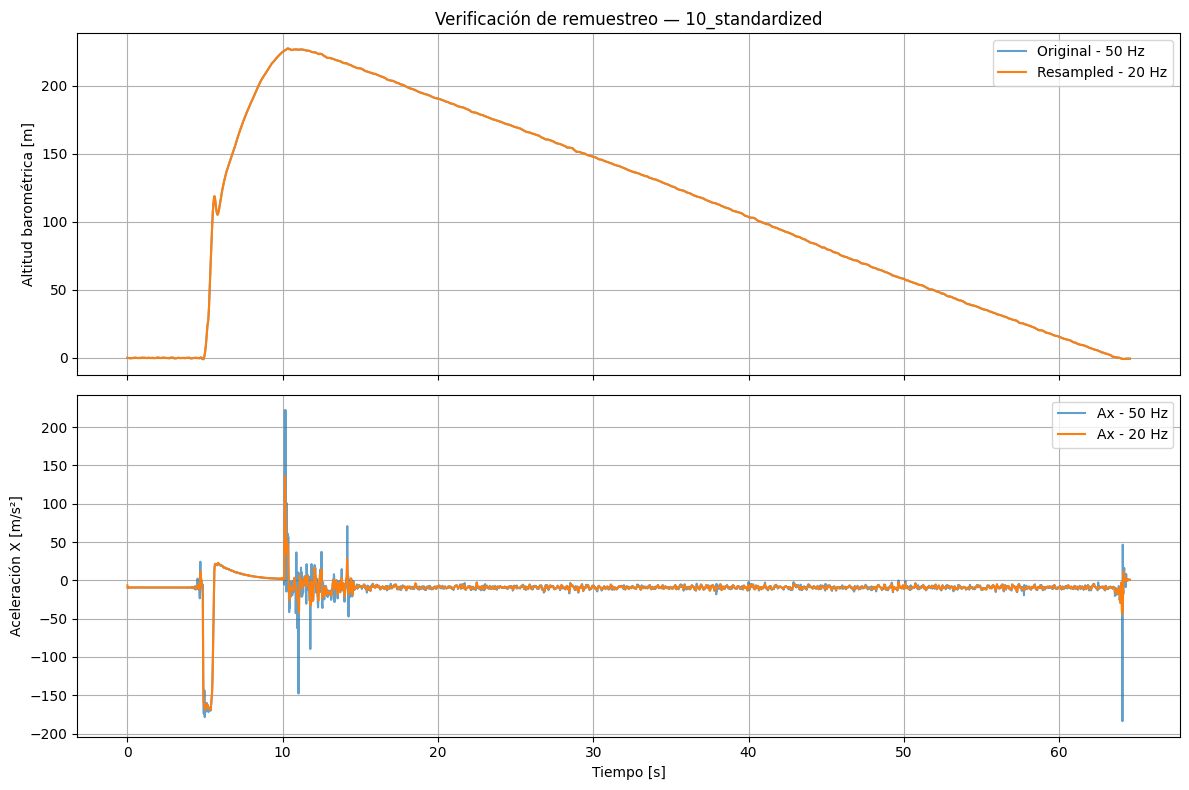

In [9]:
check_flight = flights_50hz["flight"].iloc[0] if len(flights_50hz) else None

if check_flight is not None:
    df_50_check = pd.read_csv(DATA_PATH / f"{check_flight}.csv")
    df_20_check = pd.read_csv(PROCESSED_PATH / f"{check_flight}_20Hz.csv")

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(df_50_check["time"], df_50_check["baro_altitude"], label="Original - 50 Hz", alpha=0.7)
    axes[0].plot(df_20_check["time"], df_20_check["baro_altitude"], label="Resampled - 20 Hz")
    axes[0].set_ylabel("Altitud barométrica [m]")
    axes[0].set_title(f"Verificación de remuestreo — {check_flight}")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(df_50_check["time"], df_50_check["accl_x"], label="Ax - 50 Hz", alpha=0.7)
    axes[1].plot(df_20_check["time"], df_20_check["accl_x"], label="Ax - 20 Hz")
    axes[1].set_xlabel("Tiempo [s]")
    axes[1].set_ylabel("Aceleración X [m/s²]")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("No hay vuelos a 50 Hz para comparar visualmente.")


### Construcción de `df_model`

Para cada vuelo procesado a 20 Hz:
1. Se calcula la aceleración total `At = sqrt(Ax² + Ay² + Az²)`.
2. Se calculan las variables atmosféricas ISA (`T`, `P`, `rho`, `a`) a partir de la altitud barométrica.
3. Se calcula el **apogeo** (altitud máxima) de cada vuelo y se agrega como columna constante por vuelo.
4. Se concatenan todos los vuelos en un solo DataFrame.


In [10]:
flight_dfs = []

for flight in processed_flights:
    df_flight = pd.read_csv(flight["output_file"])
    df_flight["flight_id"] = flight["flight_id"]

    df_flight["At"] = np.sqrt(
        df_flight["accl_x"] ** 2 + df_flight["accl_y"] ** 2 + df_flight["accl_z"] ** 2
    )

    T, P, rho, a = isa_atmosphere(df_flight["baro_altitude"].values)
    df_flight["T"], df_flight["P"], df_flight["rho"], df_flight["a"] = T, P, rho, a

    df_flight["apogee"] = df_flight["baro_altitude"].max()

    flight_dfs.append(df_flight)

df_model = pd.concat(flight_dfs, ignore_index=True)

print("DATASET FINAL (df_model)")
print("Número de vuelos:", df_model["flight_id"].nunique())
print("Número total de muestras:", len(df_model))
print("\nValores faltantes:")
print(df_model.isna().sum())

display(df_model[[
    "flight_id", "time", "baro_altitude", "accl_x", "accl_y", "accl_z",
    "At", "T", "P", "rho", "a", "apogee",
]].head(10))


DATASET FINAL (df_model)
Número de vuelos: 51
Número total de muestras: 90784

Valores faltantes:
time             0
baro_altitude    0
accl_x           0
accl_y           0
accl_z           0
gps_altitude     0
gyro_roll        0
gyro_pitch       0
gyro_yaw         0
flight_id        0
At               0
T                0
P                0
rho              0
a                0
apogee           0
dtype: int64


,flight_id,time,baro_altitude,accl_x,accl_y,accl_z,At,T,P,rho,a,apogee
0,10_standardized,0.00,-0.003769,-6.598550,-0.241220,-0.666238,6.636484,288.150000,101325.000000,1.225012,340.292287,227.276867
1,10_standardized,0.05,-0.076606,-10.105013,-0.338132,-1.011596,10.161149,288.150000,101325.000000,1.225012,340.292287,227.276867
2,10_standardized,0.10,-0.126135,-9.109881,-0.345419,-0.896149,9.160367,288.150000,101325.000000,1.225012,340.292287,227.276867
3,10_standardized,0.15,-0.217442,-9.636053,-0.282976,-0.891976,9.681385,288.150000,101325.000000,1.225012,340.292287,227.276867
4,10_standardized,0.20,-0.327506,-9.274306,-0.312216,-0.898237,9.322932,288.150000,101325.000000,1.225012,340.292287,227.276867
5,10_standardized,0.25,-0.164664,-9.528001,-0.410902,-0.894256,9.578692,288.150000,101325.000000,1.225012,340.292287,227.276867
6,10_standardized,0.30,-0.158496,-9.306838,-0.397669,-0.907953,9.359474,288.150000,101325.000000,1.225012,340.292287,227.276867
7,10_standardized,0.35,-0.192128,-9.405325,-0.329770,-0.947291,9.458660,288.150000,101325.000000,1.225012,340.292287,227.276867
8,10_standardized,0.40,0.012741,-9.380326,-0.348000,-0.910116,9.430796,288.149917,101324.846935,1.225011,340.292238,227.276867
9,10_standardized,0.45,0.092102,-9.378948,-0.314379,-0.924028,9.429598,288.149401,101323.893559,1.225001,340.291933,227.276867


### Distribución de apogeos y detección de vuelos duplicados

Algunos vuelos del dataset original resultaron ser el mismo vuelo guardado dos veces con nombres distintos
(apogeos idénticos hasta el metro). Se detectan por diferencia de apogeo < 1 m y se eliminan los duplicados,
conservando solo el primero de cada par.


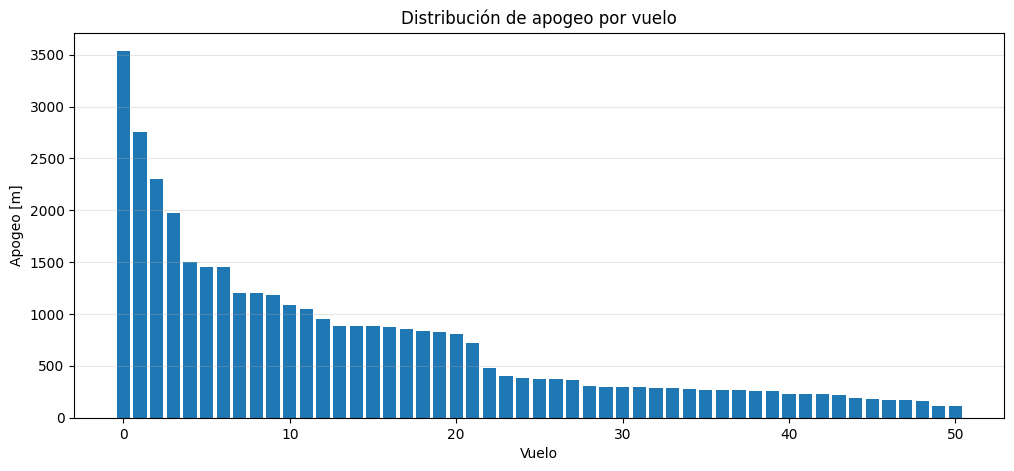

Posibles vuelos duplicados (diferencia de apogeo < 1 m):
  flightsketch6_standardized  <->  37_standardized   (Δapogeo = 0.000 m)
  36_standardized  <->  flightsketch5_standardized   (Δapogeo = 0.000 m)
  flightsketch3_standardized  <->  32_standardized   (Δapogeo = 0.000 m)
  23_standardized  <->  24_standardized   (Δapogeo = 0.000 m)
  19_standardized  <->  flightsketch8_standardized   (Δapogeo = 0.000 m)
  10_standardized  <->  9_standardized   (Δapogeo = 0.000 m)
  4_standardized  <->  e1_replicated_failure_standardized   (Δapogeo = 0.000 m)


In [11]:
apogee_by_flight = (
    df_model.groupby("flight_id")["apogee"].first().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(apogee_by_flight)), apogee_by_flight.values)
ax.set_xlabel("Vuelo")
ax.set_ylabel("Apogeo [m]")
ax.set_title("Distribución de apogeo por vuelo")
ax.grid(axis="y", alpha=0.3)
plt.show()

apogees = apogee_by_flight.reset_index()
duplicate_pairs = []
for i in range(len(apogees)):
    for j in range(i + 1, len(apogees)):
        diff = abs(apogees.loc[i, "apogee"] - apogees.loc[j, "apogee"])
        if diff < 1.0:
            duplicate_pairs.append((apogees.loc[i, "flight_id"], apogees.loc[j, "flight_id"], diff))

print("Posibles vuelos duplicados (diferencia de apogeo < 1 m):")
for f1, f2, diff in duplicate_pairs:
    print(f"  {f1}  <->  {f2}   (Δapogeo = {diff:.3f} m)")


In [12]:
# Conservamos el primer vuelo de cada par duplicado, eliminamos el segundo
flights_to_remove = [pair[1] for pair in duplicate_pairs]

df_clean = df_model[~df_model["flight_id"].isin(flights_to_remove)].copy()

print("Vuelos eliminados por duplicación:", flights_to_remove)
print("\nDATASET SIN DUPLICADOS (df_clean)")
print("Número de vuelos:", df_clean["flight_id"].nunique())
print("Número de muestras:", len(df_clean))

flight_summary = (
    df_clean.groupby("flight_id")
    .agg(samples=("time", "count"), duration_s=("time", "max"), apogee=("apogee", "first"))
    .sort_values("apogee", ascending=False)
)
display(flight_summary)

short_flights = flight_summary[flight_summary["duration_s"] < 12]
print("\nVuelos con menos de 12 s de duración:", len(short_flights))
if len(short_flights):
    display(short_flights)


Vuelos eliminados por duplicación: ['37_standardized', 'flightsketch5_standardized', '32_standardized', '24_standardized', 'flightsketch8_standardized', '9_standardized', 'e1_replicated_failure_standardized']

DATASET SIN DUPLICADOS (df_clean)
Número de vuelos: 44
Número de muestras: 78655


,samples,duration_s,apogee
flight_id,,,
custom2_standardized,6023,313.526,3535.081543
custom1_standardized,4557,235.102,2756.031494
custom3_standardized,3169,164.520,2306.110107
39_standardized,3807,190.300,1975.329127
38_standardized,2340,116.950,1500.095359
flightsketch6_standardized,2676,133.750,1450.026703
36_standardized,2132,106.550,1199.585046
35_standardized,2316,115.750,1181.335771
flightsketch2_standardized,2122,106.050,1086.203016



Vuelos con menos de 12 s de duración: 0


## Dataset tabular: características a los 6 segundos de vuelo

Se calculan características agregadas usando solo los datos disponibles hasta un instante `horizon`
(no se usa información futura del vuelo esto es clave para que el modelo sea utilizable en tiempo real durante el vuelo, y para que no haya fuga de información hacia el pasado).



In [40]:
from sklearn.preprocessing import PowerTransformer

def extract_features_physics(flight_df, horizon):
    """Extrae características físicas NO redundantes y calcula aceleración vertical."""
    data = flight_df[flight_df["time"] <= horizon]
    if len(data) < 4:
        return None

    # 1. Variables básicas en el instante final
    last = data.iloc[-1]
    
    # 2. Velocidad vertical (derivada de la altitud)
    dt = data["time"].diff()
    vel = data["baro_altitude"].diff() / dt
    vertical_velocity = vel.iloc[-1] if len(vel) > 1 else 0.0
    
    # 3. Aceleración vertical (derivada de la velocidad) - ¡NUEVA!
    acc = vel.diff() / dt
    vertical_acceleration = acc.iloc[-1] if len(acc) > 1 else 0.0
    
    # 4. Elimino redundantes (max/mean/std de At y altitud) y añado estadísticos de velocidad/aceleración
    return {
        "time": last["time"],
        "baro_altitude": last["baro_altitude"],          # Altitud actual
        "vertical_velocity": vertical_velocity,          # Velocidad actual
        "vertical_acceleration": vertical_acceleration,  # Aceleración actual (CLAVE)
        "vel_mean": vel.mean(),                          # Velocidad media
        "vel_std": vel.std(),                            # Dispersión de la velocidad
        "acc_mean": acc.mean(),                          # Aceleración media
        "acc_std": acc.std(),                            # Dispersión de la aceleración
        "At": last["At"],                                # Aceleración total actual
        "At_std": data["At"].std(),                      # Ruido de la aceleración
        "gyro_roll": last["gyro_roll"],
        "gyro_pitch": last["gyro_pitch"],
        "gyro_yaw": last["gyro_yaw"],
        "flight_id": last["flight_id"],
        "apogee": last["apogee"],                        # Target original
    }

HORIZON_S = 6
rows = [extract_features_physics(flight_df, HORIZON_S) for _, flight_df in df_clean.groupby("flight_id")]
df_6s = pd.DataFrame([r for r in rows if r is not None])

# --- TRANSFORMACIÓN DEL TARGET (LOG) ---
# Aplicamos log(apogeo) para que el modelo prediga en escala logarítmica,
# reduciendo el impacto de los vuelos de mayor altitud.
df_6s["apogee_log"] = np.log1p(df_6s["apogee"])

# Variables finales (ahora 10 características relevantes)
FEATURE_COLUMNS = [
    "baro_altitude", "vertical_velocity", "vertical_acceleration",
    "vel_mean", "vel_std", "acc_mean", "acc_std",
    "At", "At_std", "gyro_roll", "gyro_pitch", "gyro_yaw"
]

X_final = df_6s[FEATURE_COLUMNS].copy()
y_final = df_6s["apogee_log"].copy()  # <--- Objetivo transformado
flight_ids_final = df_6s["flight_id"].values

print(f"Features ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}")
print(f"Target transformado: log(apogeo+1)")

Features (12): ['baro_altitude', 'vertical_velocity', 'vertical_acceleration', 'vel_mean', 'vel_std', 'acc_mean', 'acc_std', 'At', 'At_std', 'gyro_roll', 'gyro_pitch', 'gyro_yaw']
Target transformado: log(apogeo+1)


### Selección de variables por correlación

1. Se descartan variables redundantes con correlación ~1.0 entre sí (T, rho, a están perfectamente
   correlacionadas entre ellas son todas funciones directas de la altitud vía el modelo ISA).
2. P (presión) tiene correlación de -0.996 con baro_altitude  es prácticamente la misma información.
3. Se descartan las medias de aceleración por eje (accl_x/y/z_mean), que tienen correlación casi nula con
   el apogeo (todas |r| < 0.1).


In [14]:
X_all = df_6s.drop(columns=["flight_id", "apogee"])
y_all = df_6s["apogee"]

corr_X = X_all.corr()
corr_pairs = (
    corr_X.where(np.triu(np.ones(corr_X.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: abs(s), ascending=False)
)

print("Pares con |correlación| >= 0.90:")
for (v1, v2), c in corr_pairs.items():
    if abs(c) >= 0.90:
        print(f"  {v1:20s} <-> {v2:20s} : {c:.4f}")


Pares con |correlación| >= 0.90:
  T                    <-> a                    : 1.0000
  P                    <-> rho                  : 1.0000
  T                    <-> rho                  : 0.9999
  rho                  <-> a                    : 0.9999
  T                    <-> P                    : 0.9998
  P                    <-> a                    : 0.9998
  baro_altitude        <-> rho                  : -0.9994
  baro_altitude        <-> T                    : -0.9994
  baro_altitude        <-> a                    : -0.9994
  baro_altitude        <-> P                    : -0.9994
  baro_altitude_max    <-> a                    : -0.9968
  baro_altitude_max    <-> T                    : -0.9968
  baro_altitude_max    <-> rho                  : -0.9966
  baro_altitude_max    <-> P                    : -0.9965
  baro_altitude        <-> baro_altitude_max    : 0.9941
  gyro_pitch           <-> gyro_yaw             : 0.9512
  gyro_pitch           <-> a                   

In [15]:
corr_apogee = X_all.assign(apogee=y_all).corr()["apogee"].drop("apogee").sort_values(key=abs, ascending=False)
print("Correlación de cada variable con el apogeo:")
print(corr_apogee)


Correlación de cada variable con el apogeo:
time                -0.772895
gyro_yaw             0.451927
baro_altitude        0.335162
a                   -0.333145
T                   -0.332947
rho                 -0.331597
gyro_pitch           0.331577
P                   -0.331160
baro_altitude_max    0.326236
gyro_roll           -0.323807
At_max              -0.227278
At                   0.212085
accl_y_mean          0.203334
vertical_velocity    0.160028
At_mean              0.103047
accl_x_mean          0.062688
accl_z_std          -0.055821
accl_y_std           0.021686
At_std               0.009826
accl_z_mean         -0.008561
accl_x_std           0.002496
Name: apogee, dtype: float64


In [16]:
VARS_TO_DROP = [
    "T", "rho", "a",          # redundantes entre sí (misma info que P/baro_altitude vía ISA)
    "P",                       # redundante con baro_altitude (r = -0.996)
    "accl_x_mean", "accl_y_mean", "accl_z_mean",  # correlación ~0 con el apogeo
]

FEATURE_COLUMNS = [c for c in X_all.columns if c not in VARS_TO_DROP]

X_final = X_all[FEATURE_COLUMNS].copy()
y_final = y_all.copy()
flight_ids_final = df_6s["flight_id"].values

print(f"Variables finales ({len(FEATURE_COLUMNS)}):")
for i, c in enumerate(FEATURE_COLUMNS, 1):
    print(f"  {i:2d}. {c}")

print("\nShape X_final:", X_final.shape, "  Shape y_final:", y_final.shape)


Variables finales (14):
   1. time
   2. baro_altitude
   3. baro_altitude_max
   4. vertical_velocity
   5. At
   6. At_max
   7. At_mean
   8. At_std
   9. accl_x_std
  10. accl_y_std
  11. accl_z_std
  12. gyro_roll
  13. gyro_pitch
  14. gyro_yaw

Shape X_final: (44, 14)   Shape y_final: (44,)


## 4. Partición única train/val/test (60/20/20 por vuelo)

Esta es la partición canónica que se reutiliza en todos los modelos (Regresión Lineal, Random Forest,
LSTM V1-V5). 


In [17]:
flights_train, flights_temp = train_test_split(
    flight_ids_final, test_size=0.40, random_state=RANDOM_STATE
)
flights_val, flights_test = train_test_split(
    flights_temp, test_size=0.50, random_state=RANDOM_STATE
)

train_mask = np.isin(flight_ids_final, flights_train)
val_mask = np.isin(flight_ids_final, flights_val)
test_mask = np.isin(flight_ids_final, flights_test)

X_train, y_train = X_final[train_mask], y_final[train_mask]
X_val, y_val = X_final[val_mask], y_final[val_mask]
X_test, y_test = X_final[test_mask], y_final[test_mask]

print("PARTICIÓN CANÓNICA POR VUELO")
print(f"Train: {len(X_train)} vuelos | Val: {len(X_val)} vuelos | Test: {len(X_test)} vuelos")
assert set(flights_train) & set(flights_val) == set()
assert set(flights_train) & set(flights_test) == set()
assert set(flights_val) & set(flights_test) == set()
print("Sin solapamiento entre particiones ✔")


PARTICIÓN CANÓNICA POR VUELO
Train: 26 vuelos | Val: 9 vuelos | Test: 9 vuelos
Sin solapamiento entre particiones ✔


In [18]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)   # fit SOLO con train
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("Media (debe ser ~0):", X_train_scaled.mean(axis=0).round(4))
print("Std (debe ser ~1): ", X_train_scaled.std(axis=0).round(4))


X_train_scaled: (26, 14)
Media (debe ser ~0): [ 0.  0.  0. -0.  0.  0.  0.  0.  0. -0. -0.  0. -0. -0.]
Std (debe ser ~1):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [42]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

# 1. RIDGE REGRESSION (regularización L2)
ridge_model = Ridge(alpha=10.0)

# 2. GRADIENT BOOSTING (similar a XGBoost, pero nativo de sklearn)
gbm_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    random_state=RANDOM_STATE,
    min_samples_split=5,      # Evita hojas muy específicas
    min_samples_leaf=3,
    alpha=0.9                 # Para pérdida quantile, puedes dejarlo en 0.9
)

# Evaluación con GroupKFold (usando tus funciones existentes)
cv_ridge_folds = groupkfold_evaluate_sklearn(
    lambda: Ridge(alpha=10.0), 
    X_final, y_final, groups=flight_ids_final, n_splits=5
)

cv_gbm_folds = groupkfold_evaluate_sklearn(
    lambda: GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, 
        subsample=0.7, random_state=RANDOM_STATE,
        min_samples_split=5, min_samples_leaf=3
    ),
    X_final, y_final, groups=flight_ids_final, n_splits=5
)

print("=== RIDGE CV (log) ===")
print(f"MAE: {cv_ridge_folds['MAE'].mean():.2f} ± {cv_ridge_folds['MAE'].std():.2f}")
print(f"R²:  {cv_ridge_folds['R2'].mean():.4f} ± {cv_ridge_folds['R2'].std():.4f}")

print("\n=== GRADIENT BOOSTING CV (log) ===")
print(f"MAE: {cv_gbm_folds['MAE'].mean():.2f} ± {cv_gbm_folds['MAE'].std():.2f}")
print(f"R²:  {cv_gbm_folds['R2'].mean():.4f} ± {cv_gbm_folds['R2'].std():.4f}")

=== RIDGE CV (log) ===
MAE: 0.58 ± 0.29
R²:  -0.7376 ± 2.7789

=== GRADIENT BOOSTING CV (log) ===
MAE: 0.41 ± 0.12
R²:  0.5999 ± 0.2528


## Funciones auxiliares 

Para que los 7 modelos (Regresión Lineal, Random Forest, LSTM V1-V5) se documenten y evalúen de la misma
forma, se definen funciones reutilizables en vez de repetir el mismo bloque de código 6 veces. Esto también
elimina el riesgo del bug original (usar la variable de modelo equivocada), porque cada llamada recibe y
devuelve explícitamente su propio modelo.

Plantilla para cada modelo:
1. Plantear y crear el modelo
2. Mostrar el resumen (`summary()` para Keras, o resumen de coeficientes/importancias para sklearn)
3. Entrenar
4. Mostrar métricas (MAE, RMSE, R²) sobre entrenamiento y validación
5. Graficar curva de pérdida (solo LSTM)
6. Determinar y marcar la mejor época (solo LSTM)
7. Graficar predicciones vs. valores reales del set de validación


In [19]:
def regression_metrics(y_true, y_pred):
    """MAE, RMSE y R² en las unidades originales (metros)."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def print_metrics(name, metrics):
    print(f"{name}")
    print(f"  MAE  : {metrics['MAE']:.2f} m")
    print(f"  RMSE : {metrics['RMSE']:.2f} m")
    print(f"  R²   : {metrics['R2']:.4f}")


def plot_predictions_vs_real(y_true, y_pred, title, ax=None):
    """Gráfica de dispersión: apogeo real vs. predicho, con línea ideal y = x."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(y_true, y_pred, s=60, alpha=0.75, edgecolor="k")

    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray", label="Predicción ideal (y = x)")

    ax.set_xlabel("Apogeo real [m]")
    ax.set_ylabel("Apogeo predicho [m]")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    if own_fig:
        plt.tight_layout()
        plt.show()


def evaluate_sklearn_model(name, model, X_train, y_train, X_val, y_val):
    """Entrena un modelo sklearn ya construido, imprime métricas train/val y grafica predicciones vs. real."""
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    metrics_train = regression_metrics(y_train, pred_train)
    metrics_val = regression_metrics(y_val, pred_val)

    print("=" * 60)
    print(name)
    print("=" * 60)
    print_metrics("ENTRENAMIENTO", metrics_train)
    print()
    print_metrics("VALIDACIÓN", metrics_val)

    plot_predictions_vs_real(y_val, pred_val, f"{name} — Validación")

    return model, {"train": metrics_train, "val": metrics_val}


In [ ]:
def build_lstm(name, input_shape, lstm_units, dense_units, dropout, loss="mse", learning_rate=1e-3):
    """Construye y compila un modelo LSTM: Input -> LSTM -> Dropout -> Dense(relu) -> Dense(1)."""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(lstm_units),
        Dropout(dropout),
        Dense(dense_units, activation="relu"),
        Dense(1),
    ], name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def train_lstm(model, X_train, y_train, X_val, y_val, epochs=150, batch_size=32, patience=15):
    """Entrena con EarlyStopping (restaura mejores pesos) + ReduceLROnPlateau. Imprime la mejor época."""
    early_stop = EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=max(3, patience // 2), min_lr=1e-6, verbose=0
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=0,
    )

    val_losses = history.history["val_loss"]
    best_epoch = int(np.argmin(val_losses)) + 1     # +1 porque las épocas se numeran desde 1
    best_val_loss = val_losses[best_epoch - 1]

    print(f"Épocas ejecutadas : {len(val_losses)}")
    print(f"Mejor época        : {best_epoch} (de {len(val_losses)})")
    print(f"Mejor loss train   : {min(history.history['loss']):.4f}")
    print(f"Mejor loss val     : {best_val_loss:.4f}")

    return history, best_epoch


def plot_loss_curve(history, best_epoch, title):
    """Curva de pérdida train/val, marcando la mejor época con una línea vertical."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(history.history["loss"], label="Entrenamiento")
    ax.plot(history.history["val_loss"], label="Validación")
    ax.axvline(best_epoch - 1, linestyle="--", color="gray", label=f"Mejor época ({best_epoch})")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida (loss)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def evaluate_lstm_model(
    name, model, X_train, y_train, X_val, y_val,
    epochs=150, batch_size=32, patience=15,
    scaler_y=None,
):
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    model.summary()

    history, best_epoch = train_lstm(
        model, X_train, y_train, X_val, y_val,
        epochs=epochs, batch_size=batch_size, patience=patience,
    )

    plot_loss_curve(history, best_epoch, f"{name} — Curva de pérdida")

    pred_val_scaled = model.predict(X_val, verbose=0).ravel()
    y_val_arr = np.asarray(y_val).ravel()

    if scaler_y is not None:
        pred_val = scaler_y.inverse_transform(pred_val_scaled.reshape(-1, 1)).ravel()
        y_val_real = scaler_y.inverse_transform(y_val_arr.reshape(-1, 1)).ravel()
    else:
        pred_val = pred_val_scaled
        y_val_real = y_val_arr

    metrics_val = regression_metrics(y_val_real, pred_val)
    print()
    print_metrics("VALIDACIÓN (metros)", metrics_val)

    plot_predictions_vs_real(y_val_real, pred_val, f"{name} — Validación")

    return model, history, {"best_epoch": best_epoch, "val": metrics_val}


## Modelo base (baseline): predicción con la media

In [21]:
baseline_value = y_train.mean()
y_val_baseline = np.full(len(y_val), baseline_value)

metrics_baseline = regression_metrics(y_val, y_val_baseline)
print(f"Media del apogeo en entrenamiento: {baseline_value:.2f} m\n")
print_metrics("MODELO BASE — Validación", metrics_baseline)

results = {}  # aquí se acumulan las métricas de validación de todos los modelos para la comparación final
results["Baseline (media)"] = metrics_baseline


Media del apogeo en entrenamiento: 653.22 m

MODELO BASE — Validación
  MAE  : 371.94 m
  RMSE : 386.08 m
  R²   : -0.4823


##  Regresión Lineal

Modelo simple de referencia antes de pasar a modelos más complejos (Random Forest, LSTM).


REGRESIÓN LINEAL
ENTRENAMIENTO
  MAE  : 49.99 m
  RMSE : 68.37 m
  R²   : 0.9881

VALIDACIÓN
  MAE  : 350.43 m
  RMSE : 587.67 m
  R²   : -2.4344


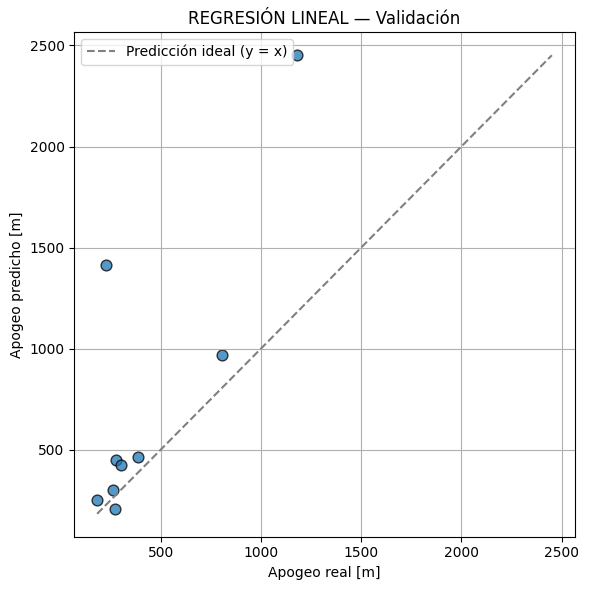


Coeficientes:
  time                :    -136.22
  baro_altitude       :    -790.76
  baro_altitude_max   :     704.76
  vertical_velocity   :     163.61
  At                  :     152.59
  At_max              :     -25.63
  At_mean             :     467.02
  At_std              :    -133.50
  accl_x_std          :     -29.80
  accl_y_std          :     -20.34
  accl_z_std          :      35.60
  gyro_roll           :    -136.22
  gyro_pitch          :     136.22
  gyro_yaw            :     136.22


In [22]:
modelo_lr = LinearRegression()
modelo_lr, metrics_lr = evaluate_sklearn_model(
    "REGRESIÓN LINEAL", modelo_lr, X_train_scaled, y_train, X_val_scaled, y_val
)

print("\nCoeficientes:")
for feat, coef in zip(FEATURE_COLUMNS, modelo_lr.coef_):
    print(f"  {feat:20s}: {coef:10.2f}")

results["Regresión Lineal"] = metrics_lr["val"]


## Random Forest

RANDOM FOREST
ENTRENAMIENTO
  MAE  : 98.03 m
  RMSE : 228.98 m
  R²   : 0.8666

VALIDACIÓN
  MAE  : 176.72 m
  RMSE : 220.47 m
  R²   : 0.5166


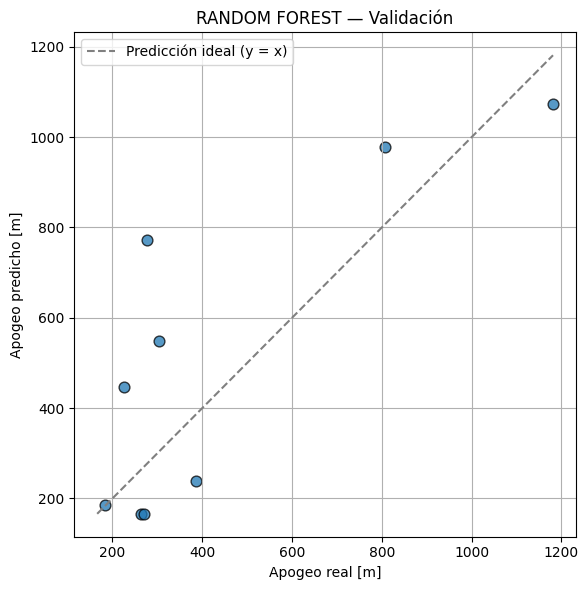


Importancia de variables:
At_mean              0.318373
vertical_velocity    0.221364
At_std               0.073478
accl_y_std           0.056066
gyro_pitch           0.049980
At                   0.047946
accl_x_std           0.047509
accl_z_std           0.040048
gyro_yaw             0.036526
baro_altitude_max    0.028427
gyro_roll            0.022657
baro_altitude        0.021578
time                 0.018048
At_max               0.018002
dtype: float64


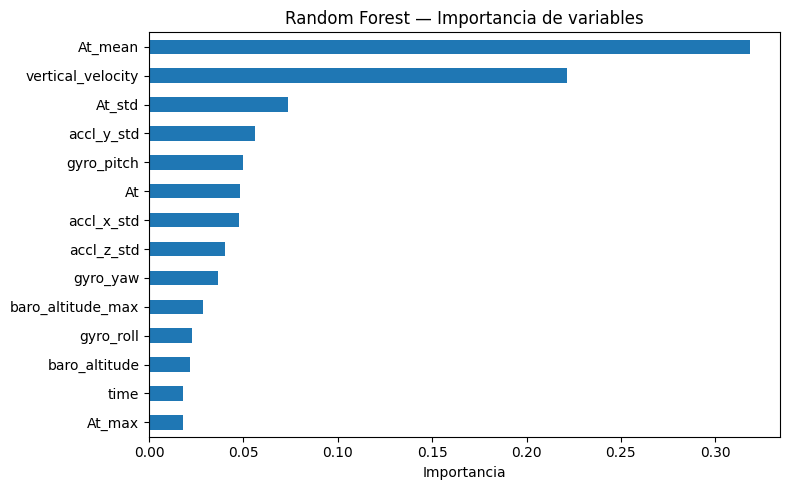

In [23]:
modelo_rf = RandomForestRegressor(
    n_estimators=200, max_depth=5, random_state=RANDOM_STATE
)
modelo_rf, metrics_rf = evaluate_sklearn_model(
    "RANDOM FOREST", modelo_rf, X_train_scaled, y_train, X_val_scaled, y_val
)

importances = pd.Series(modelo_rf.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
print("\nImportancia de variables:")
print(importances)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Random Forest — Importancia de variables")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

results["Random Forest"] = metrics_rf["val"]


## Dataset secuencial para LSTM (una ventana de 6 s por vuelo)

A diferencia del dataset tabular (que resume los primeros 6 s en unas pocas estadísticas), aquí se conserva
la secuencia temporal completa de los primeros 6 s de cada vuelo (121 muestras a 20 Hz), para que la LSTM
pueda aprender de la forma de la señal y no solo de resúmenes estadísticos.

Se usa la misma partición canónica por vuelo (`flights_train/val/test`) definida en la sección 4, para
que LSTM V1-V3 sean directamente comparables con Regresión Lineal y Random Forest.


In [24]:
WINDOW_SIZE_V1 = 121   # 6.05 s a 20 Hz (igual que el horizonte tabular de 6 s)
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_sequences, y_sequences, flight_ids_seq = [], [], []

for flight_id, flight_df in df_clean.groupby("flight_id"):
    flight_df = flight_df.sort_values("time")
    window = flight_df.iloc[:WINDOW_SIZE_V1]
    if len(window) != WINDOW_SIZE_V1:
        continue
    X_sequences.append(window[FEATURES_LSTM].values)
    y_sequences.append(window["apogee"].iloc[0])
    flight_ids_seq.append(flight_id)

X_seq = np.array(X_sequences, dtype=np.float32)
y_seq = np.array(y_sequences, dtype=np.float32)
flight_ids_seq = np.array(flight_ids_seq)

print("X_seq:", X_seq.shape, " y_seq:", y_seq.shape)
print("Vuelos incluidos:", len(flight_ids_seq))


X_seq: (44, 121, 6)  y_seq: (44,)
Vuelos incluidos: 44


In [25]:
# Reutilizamos exactamente la misma partición de vuelos que en la sección 4
seq_train_mask = np.isin(flight_ids_seq, flights_train)
seq_val_mask = np.isin(flight_ids_seq, flights_val)
seq_test_mask = np.isin(flight_ids_seq, flights_test)

X_seq_train, y_seq_train = X_seq[seq_train_mask], y_seq[seq_train_mask]
X_seq_val, y_seq_val = X_seq[seq_val_mask], y_seq[seq_val_mask]
X_seq_test, y_seq_test = X_seq[seq_test_mask], y_seq[seq_test_mask]

print(f"Train: {X_seq_train.shape} | Val: {X_seq_val.shape} | Test: {X_seq_test.shape}")


Train: (26, 121, 6) | Val: (9, 121, 6) | Test: (9, 121, 6)


In [26]:
# Escalamiento de X (3D -> 2D -> fit con train -> 3D)
n_features_seq = X_seq_train.shape[2]
scaler_X_seq = StandardScaler()

X_seq_train_scaled = scaler_X_seq.fit_transform(
    X_seq_train.reshape(-1, n_features_seq)
).reshape(X_seq_train.shape)

X_seq_val_scaled = scaler_X_seq.transform(
    X_seq_val.reshape(-1, n_features_seq)
).reshape(X_seq_val.shape)

X_seq_test_scaled = scaler_X_seq.transform(
    X_seq_test.reshape(-1, n_features_seq)
).reshape(X_seq_test.shape)

# Escalamiento de y (se usa en V2, V3 y V4; V1 lo deja sin escalar a propósito, ver más abajo)
scaler_y_seq = StandardScaler()
y_seq_train_scaled = scaler_y_seq.fit_transform(y_seq_train.reshape(-1, 1)).ravel()
y_seq_val_scaled = scaler_y_seq.transform(y_seq_val.reshape(-1, 1)).ravel()
y_seq_test_scaled = scaler_y_seq.transform(y_seq_test.reshape(-1, 1)).ravel()

print("Escalamiento listo. Media/std de X_train (deben ser ~0/~1):")
print(X_seq_train_scaled.reshape(-1, n_features_seq).mean(axis=0).round(3))
print(X_seq_train_scaled.reshape(-1, n_features_seq).std(axis=0).round(3))


Escalamiento listo. Media/std de X_train (deben ser ~0/~1):
[-0. -0.  0.  0.  0.  0.]
[1. 1. 1. 1. 1. 1.]


## LSTM V1 — arquitectura base

`LSTM(32) -> Dropout(0.2) -> Dense(16, relu) -> Dense(1)`, con `y` **sin escalar** (se predice directamente
en metros). Es la primera iteración; sirve como referencia para las siguientes versiones.


LSTM V1 (y sin escalar)


Model: "lstm_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

Épocas ejecutadas : 150
Mejor época        : 150 (de 150)
Mejor loss train   : 573781.2500
Mejor loss val     : 146010.6250


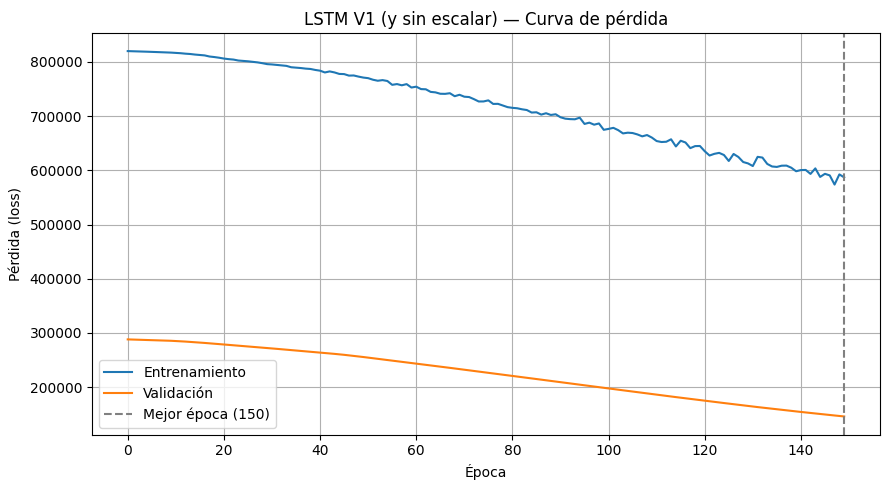


VALIDACIÓN (metros)
  MAE  : 221.50 m
  RMSE : 382.11 m
  R²   : -0.4520


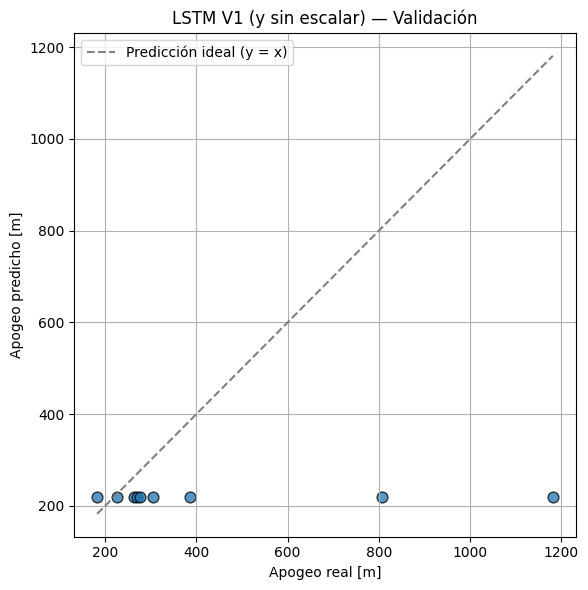

In [27]:
model_v1 = build_lstm(
    "lstm_v1", input_shape=(WINDOW_SIZE_V1, n_features_seq),
    lstm_units=32, dense_units=16, dropout=0.2, loss="mse",
)

model_v1, history_v1, metrics_v1 = evaluate_lstm_model(
    "LSTM V1 (y sin escalar)", model_v1,
    X_seq_train_scaled, y_seq_train, X_seq_val_scaled, y_seq_val,
    epochs=150, batch_size=8, patience=15,
    scaler_y=None,
)

results["LSTM V1"] = metrics_v1["val"]


## LSTM V2 — misma arquitectura, `y` escalada

Escalar también el objetivo (`apogee`) suele ayudar a que la red converja más rápido y de forma más estable,
porque todas las variables (entrada y salida) quedan en rangos numéricos similares.


LSTM V2 (y escalada)


Model: "lstm_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

Épocas ejecutadas : 21
Mejor época        : 6 (de 21)
Mejor loss train   : 0.3241
Mejor loss val     : 0.3113


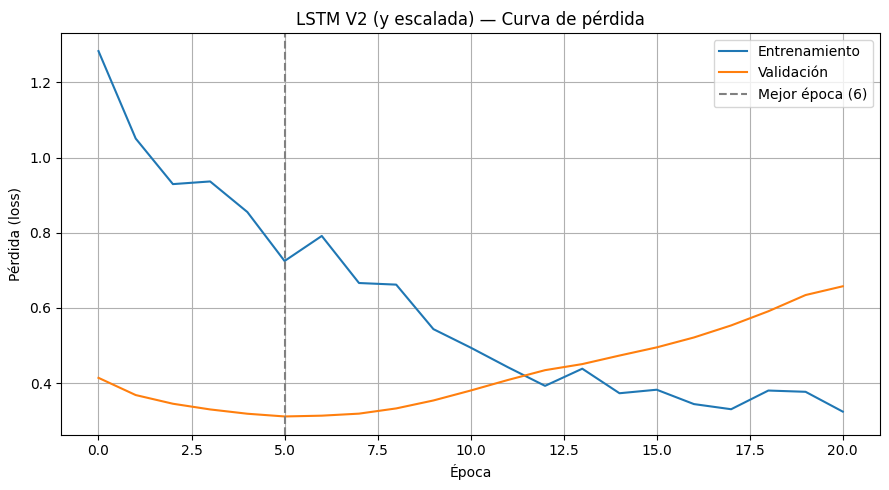


VALIDACIÓN (metros)
  MAE  : 307.69 m
  RMSE : 349.83 m
  R²   : -0.2170


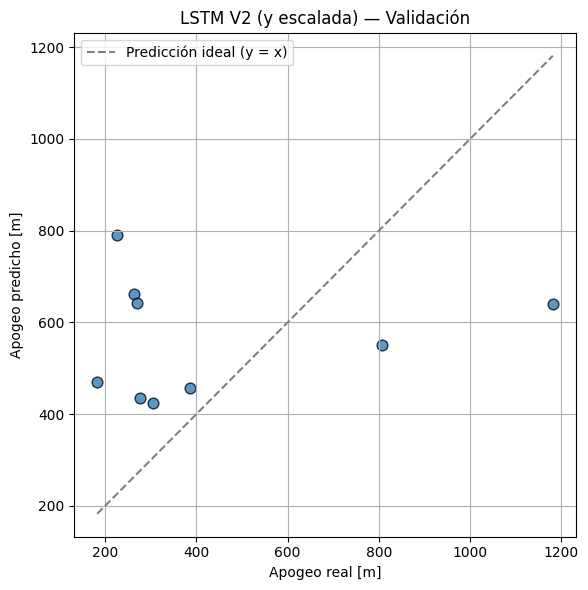

In [28]:
model_v2 = build_lstm(
    "lstm_v2", input_shape=(WINDOW_SIZE_V1, n_features_seq),
    lstm_units=32, dense_units=16, dropout=0.2, loss="mse",
)

model_v2, history_v2, metrics_v2 = evaluate_lstm_model(
    "LSTM V2 (y escalada)", model_v2,
    X_seq_train_scaled, y_seq_train_scaled, X_seq_val_scaled, y_seq_val_scaled,
    epochs=150, batch_size=8, patience=15,
    scaler_y=scaler_y_seq,
)

results["LSTM V2"] = metrics_v2["val"]


## LSTM V3 — arquitectura más pequeña + Huber loss

Con tan pocos vuelos de entrenamiento, un modelo más chico (menos parámetros) puede generalizar mejor.
También se cambia la función de pérdida a **Huber** (combina MSE y MAE, es menos sensible a outliers).


LSTM V3 (Huber loss, arquitectura reducida)


Model: "lstm_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,617 (6.32 KB)

 Trainable params: 1,617 (6.32 KB)

 Non-trainable params: 0 (0.00 B)

Épocas ejecutadas : 48
Mejor época        : 28 (de 48)
Mejor loss train   : 0.1209
Mejor loss val     : 0.0778


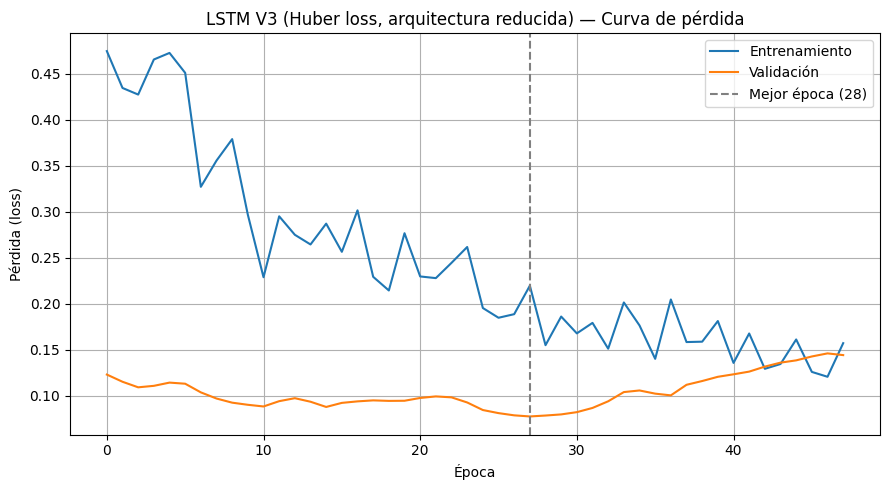


VALIDACIÓN (metros)
  MAE  : 187.59 m
  RMSE : 247.29 m
  R²   : 0.3919


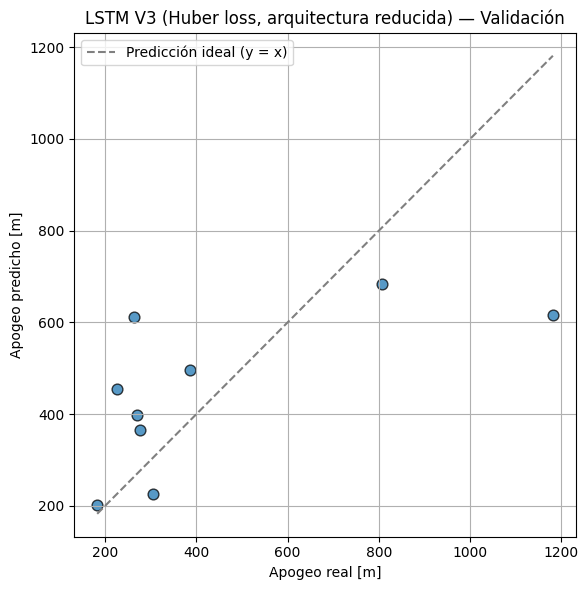

In [29]:
model_v3 = build_lstm(
    "lstm_v3", input_shape=(WINDOW_SIZE_V1, n_features_seq),
    lstm_units=16, dense_units=8, dropout=0.30, loss=Huber(),
)

model_v3, history_v3, metrics_v3 = evaluate_lstm_model(
    "LSTM V3 (Huber loss, arquitectura reducida)", model_v3,
    X_seq_train_scaled, y_seq_train_scaled, X_seq_val_scaled, y_seq_val_scaled,
    epochs=300, batch_size=4, patience=20,
    scaler_y=scaler_y_seq,
)

results["LSTM V3"] = metrics_v3["val"]


##  Dataset con ventanas deslizantes (predicción durante el vuelo)

En vez de una sola ventana de 6 s por vuelo, aquí se generan múltiples ventanas por vuelo (una cada
segundo), todas etiquetadas con el apogeo final del vuelo. Esto simula predecir el apogeo en distintos
momentos según va avanzando el vuelo, y da muchas más muestras de entrenamiento (miles de ventanas en vez
de ~40).



In [30]:
FS = 20                     # Hz
PREDICTION_TIME = 6         # segundos de observación
WINDOW_SIZE_V4 = FS * PREDICTION_TIME   # 120 muestras
STEP_SIZE = FS               # nueva ventana cada 1 segundo

X_temporal, y_temporal, flight_ids_temporal = [], [], []

for flight_id, flight_df in df_clean.groupby("flight_id"):
    flight_df = flight_df.sort_values("time").reset_index(drop=True)
    n_samples = len(flight_df)
    if n_samples < WINDOW_SIZE_V4:
        continue

    apogee_value = flight_df["apogee"].iloc[0]

    for start in range(0, n_samples - WINDOW_SIZE_V4 + 1, STEP_SIZE):
        window = flight_df.iloc[start:start + WINDOW_SIZE_V4]
        if len(window) != WINDOW_SIZE_V4:
            continue
        X_temporal.append(window[FEATURES_LSTM].values)
        y_temporal.append(apogee_value)
        flight_ids_temporal.append(flight_id)

X_temporal = np.array(X_temporal, dtype=np.float32)
y_temporal = np.array(y_temporal, dtype=np.float32)
flight_ids_temporal = np.array(flight_ids_temporal)

print(f"Ventanas totales : {len(X_temporal)}")
print(f"Shape X          : {X_temporal.shape}")
print(f"Vuelos usados    : {len(np.unique(flight_ids_temporal))}")
print("\nVentanas por vuelo:")
print(pd.Series(flight_ids_temporal).value_counts().sort_index())


Ventanas totales : 3694
Shape X          : (3694, 120, 6)
Vuelos usados    : 44

Ventanas por vuelo:
10_standardized                59
11_standardized                11
12_standardized                46
13_standardized                54
14_standardized                69
15_standardized                48
16_standardized                62
17_standardized                64
18_standardized                45
19_standardized                45
1_standardized                 45
20_standardized                89
21_standardized                45
22_standardized                56
23_standardized                94
25_standardized                45
26_standardized                45
27_standardized                82
28_standardized                71
29_standardized                73
2_standardized                 45
30_standardized               163
31_standardized                77
33_standardized                78
34_standardized                91
35_standardized               110
36_standardized

In [31]:
# División por vuelo (60/20/20) — usamos los MISMOS vuelos que la partición canónica cuando es posible,
# restringidos a los vuelos que sí alcanzan la duración mínima para generar ventanas.
unique_flights_temporal = np.unique(flight_ids_temporal)

flights_train_v4 = np.intersect1d(flights_train, unique_flights_temporal)
flights_val_v4 = np.intersect1d(flights_val, unique_flights_temporal)
flights_test_v4 = np.intersect1d(flights_test, unique_flights_temporal)

# Vuelos que cumplen duración mínima pero no estaban en la partición canónica (por si algún vuelo corto
# quedó fuera de df_6s/X_seq): se asignan a train para no perderlos.
leftover = np.setdiff1d(unique_flights_temporal, np.concatenate([flights_train_v4, flights_val_v4, flights_test_v4]))
flights_train_v4 = np.concatenate([flights_train_v4, leftover])

print(f"Vuelos train: {len(flights_train_v4)} | val: {len(flights_val_v4)} | test: {len(flights_test_v4)}")

train_mask_v4 = np.isin(flight_ids_temporal, flights_train_v4)
val_mask_v4 = np.isin(flight_ids_temporal, flights_val_v4)
test_mask_v4 = np.isin(flight_ids_temporal, flights_test_v4)

X_train_v4, y_train_v4 = X_temporal[train_mask_v4], y_temporal[train_mask_v4]
X_val_v4, y_val_v4 = X_temporal[val_mask_v4], y_temporal[val_mask_v4]
X_test_v4, y_test_v4 = X_temporal[test_mask_v4], y_temporal[test_mask_v4]

# Guardamos los flight_ids de cada partición explícitamente (en el notebook original NO se guardaban,
# lo que impedía verificar después que no hubiera solapamiento)
flight_ids_train_v4 = flight_ids_temporal[train_mask_v4]
flight_ids_val_v4 = flight_ids_temporal[val_mask_v4]
flight_ids_test_v4 = flight_ids_temporal[test_mask_v4]

print(f"\nVentanas -> Train: {X_train_v4.shape} | Val: {X_val_v4.shape} | Test: {X_test_v4.shape}")


Vuelos train: 26 | val: 9 | test: 9

Ventanas -> Train: (2129, 120, 6) | Val: (557, 120, 6) | Test: (1008, 120, 6)


In [32]:
# Verificación explícita de que no hay fuga entre particiones
train_set, val_set, test_set = set(flights_train_v4), set(flights_val_v4), set(flights_test_v4)

print("Solapamiento TRAIN-VAL :", train_set & val_set)
print("Solapamiento TRAIN-TEST:", train_set & test_set)
print("Solapamiento VAL-TEST  :", val_set & test_set)
assert not (train_set & val_set) and not (train_set & test_set) and not (val_set & test_set)
print("\nSin fuga de vuelos entre particiones ✔")


Solapamiento TRAIN-VAL : set()
Solapamiento TRAIN-TEST: set()
Solapamiento VAL-TEST  : set()

Sin fuga de vuelos entre particiones ✔


In [33]:
n_features_v4 = X_train_v4.shape[2]

scaler_X_v4 = StandardScaler()
X_train_v4_scaled = scaler_X_v4.fit_transform(X_train_v4.reshape(-1, n_features_v4)).reshape(X_train_v4.shape)
X_val_v4_scaled = scaler_X_v4.transform(X_val_v4.reshape(-1, n_features_v4)).reshape(X_val_v4.shape)
X_test_v4_scaled = scaler_X_v4.transform(X_test_v4.reshape(-1, n_features_v4)).reshape(X_test_v4.shape)

scaler_y_v4 = StandardScaler()
y_train_v4_scaled = scaler_y_v4.fit_transform(y_train_v4.reshape(-1, 1)).ravel()
y_val_v4_scaled = scaler_y_v4.transform(y_val_v4.reshape(-1, 1)).ravel()
y_test_v4_scaled = scaler_y_v4.transform(y_test_v4.reshape(-1, 1)).ravel()

print("Escalamiento del dataset temporal listo:", X_train_v4_scaled.shape)


Escalamiento del dataset temporal listo: (2129, 120, 6)


#LSTM V4 — dataset de ventanas deslizantes

Misma arquitectura base (LSTM(32) -> Dropout(0.2) -> Dense(16, relu) -> Dense(1)), pero entrenada sobre
el dataset de ventanas deslizantes (muchas más muestras, aunque provenientes de menos vuelos únicos).



LSTM V4 (ventanas deslizantes)


Model: "lstm_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

Épocas ejecutadas : 26
Mejor época        : 11 (de 26)
Mejor loss train   : 0.0928
Mejor loss val     : 0.2168


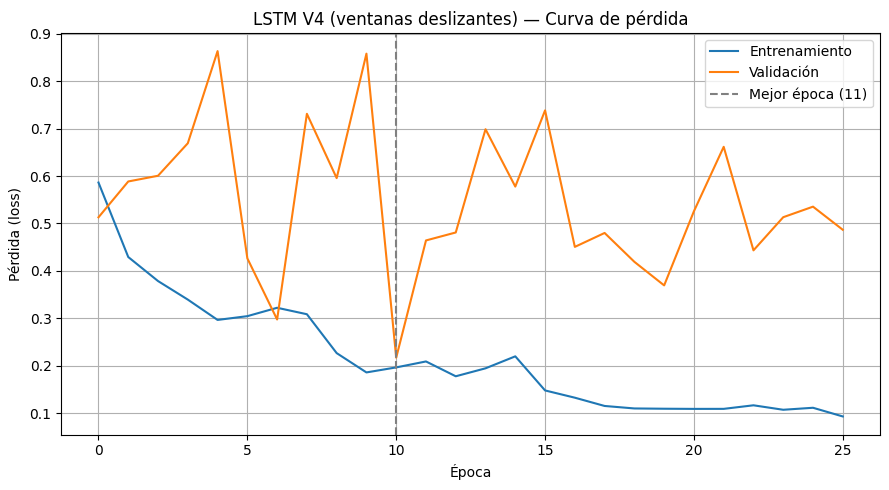


VALIDACIÓN (metros)
  MAE  : 284.44 m
  RMSE : 374.99 m
  R²   : 0.0001


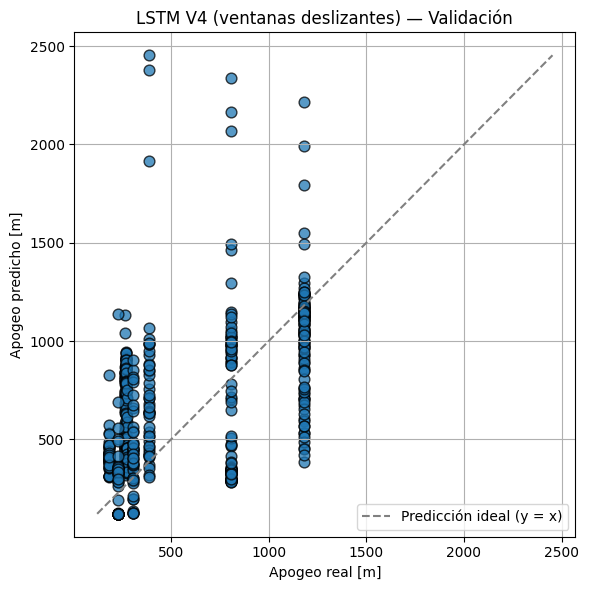

In [34]:
model_v4 = build_lstm(
    "lstm_v4", input_shape=(WINDOW_SIZE_V4, n_features_v4),
    lstm_units=32, dense_units=16, dropout=0.2, loss="mse",
)

model_v4, history_v4, metrics_v4 = evaluate_lstm_model(
    "LSTM V4 (ventanas deslizantes)", model_v4,
    X_train_v4_scaled, y_train_v4_scaled, X_val_v4_scaled, y_val_v4_scaled,
    epochs=150, batch_size=32, patience=15,
    scaler_y=scaler_y_v4,
)

results["LSTM V4"] = metrics_v4["val"]


LSTM V4 — TEST (metros)
  MAE  : 670.77 m
  RMSE : 868.45 m
  R²   : 0.4765


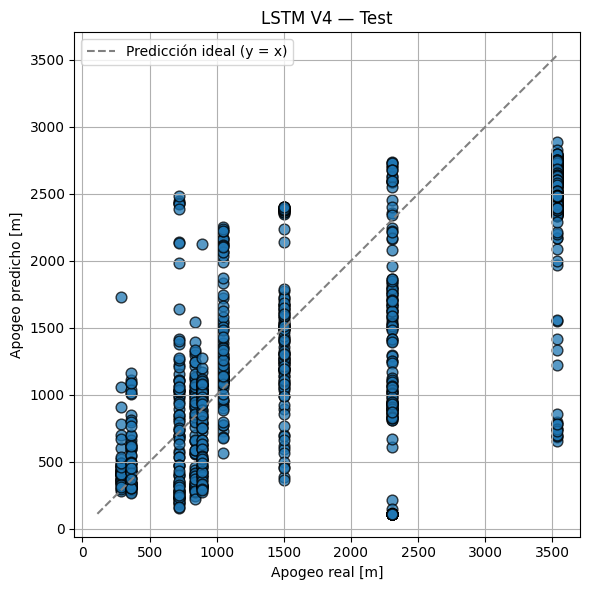

In [43]:
# Evaluación también sobre TEST (el notebook original nunca llegó a calcular esto para V4)
pred_test_v4_scaled = model_v4.predict(X_test_v4_scaled, verbose=0).ravel()
pred_test_v4 = scaler_y_v4.inverse_transform(pred_test_v4_scaled.reshape(-1, 1)).ravel()
y_test_v4_real = scaler_y_v4.inverse_transform(y_test_v4_scaled.reshape(-1, 1)).ravel()

metrics_v4_test = regression_metrics(y_test_v4_real, pred_test_v4)
print_metrics("LSTM V4 — TEST (metros)", metrics_v4_test)
plot_predictions_vs_real(y_test_v4_real, pred_test_v4, "LSTM V4 — Test")


In [ ]:
# LSTM V5 CORREGIDA (con transformación log)

# 1. Transformar el target a log
y_temporal_log = np.log1p(y_temporal)  # <--- ESTO ES CLAVE

# 2. División por vuelo (usando tus splits existentes)
train_mask_v5 = np.isin(flight_ids_temporal, flights_train_v4)
val_mask_v5 = np.isin(flight_ids_temporal, flights_val_v4)
test_mask_v5 = np.isin(flight_ids_temporal, flights_test_v4)

X_train_v5, y_train_v5 = X_temporal[train_mask_v5], y_temporal_log[train_mask_v5]
X_val_v5, y_val_v5 = X_temporal[val_mask_v5], y_temporal_log[val_mask_v5]
X_test_v5, y_test_v5 = X_temporal[test_mask_v5], y_temporal_log[test_mask_v5]

# 3. Escalar X (3D -> 2D -> fit -> 3D)
n_feat_v5 = X_train_v5.shape[2]
scaler_X_v5 = StandardScaler()
X_train_v5_scaled = scaler_X_v5.fit_transform(X_train_v5.reshape(-1, n_feat_v5)).reshape(X_train_v5.shape)
X_val_v5_scaled = scaler_X_v5.transform(X_val_v5.reshape(-1, n_feat_v5)).reshape(X_val_v5.shape)
X_test_v5_scaled = scaler_X_v5.transform(X_test_v5.reshape(-1, n_feat_v5)).reshape(X_test_v5.shape)

# 4. Escalar y (en escala log)
scaler_y_v5 = StandardScaler()
y_train_v5_scaled = scaler_y_v5.fit_transform(y_train_v5.reshape(-1, 1)).ravel()
y_val_v5_scaled = scaler_y_v5.transform(y_val_v5.reshape(-1, 1)).ravel()
y_test_v5_scaled = scaler_y_v5.transform(y_test_v5.reshape(-1, 1)).ravel()

In [51]:
# ==========================================
# EVALUACIÓN CON GROUPKFOLD PARA LSTM V5
# ==========================================

# Definimos el builder para LSTM V5 (con GRU bidireccional, dropout, regularización)
def build_lstm_v5_cv(input_shape):
    from tensorflow.keras.layers import GRU, GaussianNoise, BatchNormalization
    from tensorflow.keras.regularizers import l2
    
    model = Sequential(name="LSTM_V5_CV")
    model.add(Input(shape=input_shape))
    model.add(GaussianNoise(0.05))
    model.add(GRU(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    return model

# Ahora ejecutamos GroupKFold con 5 folds (usando y_temporal_log como target)
print("Corriendo GroupKFold para LSTM V5 (puede tardar varios minutos)...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_cv,
    X=X_temporal,
    y=y_temporal_log,  # <--- USAMOS LOG
    groups=flight_ids_temporal,
    n_splits=5,
    epochs=150,
    batch_size=64,
    patience=20
)

# Resumen de resultados
cv_lstm_v5_summary = summarize_cv(cv_lstm_v5_folds, "LSTM V5 — CV")
results["LSTM V5 (CV)"] = {
    "MAE": cv_lstm_v5_summary["MAE"],
    "RMSE": cv_lstm_v5_summary["RMSE"],
    "R2": cv_lstm_v5_summary["R2"]
}

Corriendo GroupKFold para LSTM V5 (puede tardar varios minutos)...
  Fold 1/5 listo — R² = 0.456
  Fold 2/5 listo — R² = 0.709
  Fold 3/5 listo — R² = 0.445
  Fold 4/5 listo — R² = 0.231
  Fold 5/5 listo — R² = 0.375
LSTM V5 — CV — 5 folds (GroupKFold por vuelo)


,fold,n_val_flights,MAE,RMSE,R2
0,1,8,0.689210,0.825011,0.456091
1,2,9,0.405706,0.494395,0.708871
2,3,9,0.561098,0.693358,0.445419
3,4,9,0.544853,0.673080,0.230878
4,5,9,0.410806,0.609255,0.374950



MAE  : 0.52 ± 0.12 m
RMSE : 0.66 ± 0.12 m
R²   : 0.4432 ± 0.1736


In [52]:
def groupkfold_evaluate_lstm_log(build_fn, X, y_log, groups, n_splits=5, epochs=100, batch_size=32, patience=10):
    """Similar a groupkfold_evaluate_lstm, pero y está en log(apogeo+1) y devuelve métricas en metros reales."""
    gkf = GroupKFold(n_splits=n_splits)
    n_feat = X.shape[2]
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_log, groups=groups), start=1):
        X_tr_raw, X_va_raw = X[train_idx], X[val_idx]
        y_tr_raw_log, y_va_raw_log = y_log[train_idx], y_log[val_idx]

        scaler_X_fold = StandardScaler()
        X_tr = scaler_X_fold.fit_transform(X_tr_raw.reshape(-1, n_feat)).reshape(X_tr_raw.shape)
        X_va = scaler_X_fold.transform(X_va_raw.reshape(-1, n_feat)).reshape(X_va_raw.shape)

        scaler_y_fold = StandardScaler()
        y_tr_scaled = scaler_y_fold.fit_transform(y_tr_raw_log.reshape(-1, 1)).ravel()
        y_va_scaled = scaler_y_fold.transform(y_va_raw_log.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X.shape[1], n_feat))
        early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0)
        model.fit(X_tr, y_tr_scaled, validation_data=(X_va, y_va_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        pred_scaled = model.predict(X_va, verbose=0).ravel()
        pred_log = scaler_y_fold.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
        pred_real = np.expm1(pred_log)  # Convertir de log a metros

        y_val_real = np.expm1(y_va_raw_log)  # Convertir real de log a metros

        m = regression_metrics(y_val_real, pred_real)
        m["fold"] = fold
        m["n_val_flights"] = len(np.unique(np.asarray(groups)[val_idx]))
        fold_metrics.append(m)
        print(f"  Fold {fold}/{n_splits} listo — R² = {m['R2']:.3f}")

    return pd.DataFrame(fold_metrics)

# Validación cruzada robusta con GroupKFold (agrupada por vuelo)

Un solo split train/val/test, puede ser muy sensible a qué vuelos cayeron en
cada partición por azar. GroupKFold agrupado por flight_id entrena y evalúa el modelo varias veces con
distintas combinaciones de vuelos, sin que ninguna ventana de un mismo vuelo aparezca en train y en
validación al mismo tiempo — dando una estimación más confiable del desempeño real.



In [35]:
def groupkfold_evaluate_sklearn(model_builder, X, y, groups, n_splits=5):
    """Evalúa un modelo sklearn con GroupKFold agrupado por vuelo. `model_builder` es una función
    sin argumentos que devuelve un modelo sklearn nuevo (sin entrenar) en cada fold."""
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx])
        X_va = scaler.transform(X.iloc[val_idx] if hasattr(X, "iloc") else X[val_idx])

        y_tr = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
        y_va = y.iloc[val_idx] if hasattr(y, "iloc") else y[val_idx]

        model = model_builder()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)

        m = regression_metrics(y_va, pred)
        m["fold"] = fold
        m["n_val_flights"] = len(np.unique(np.asarray(groups)[val_idx]))
        fold_metrics.append(m)

    return pd.DataFrame(fold_metrics)


def summarize_cv(df_folds, name):
    print(f"{name} — {len(df_folds)} folds (GroupKFold por vuelo)")
    display(df_folds[["fold", "n_val_flights", "MAE", "RMSE", "R2"]])
    print(f"\nMAE  : {df_folds['MAE'].mean():.2f} ± {df_folds['MAE'].std():.2f} m")
    print(f"RMSE : {df_folds['RMSE'].mean():.2f} ± {df_folds['RMSE'].std():.2f} m")
    print(f"R²   : {df_folds['R2'].mean():.4f} ± {df_folds['R2'].std():.4f}")
    return {
        "MAE": df_folds["MAE"].mean(), "MAE_std": df_folds["MAE"].std(),
        "RMSE": df_folds["RMSE"].mean(), "RMSE_std": df_folds["RMSE"].std(),
        "R2": df_folds["R2"].mean(), "R2_std": df_folds["R2"].std(),
    }


In [36]:
N_SPLITS = 5

cv_rf_folds = groupkfold_evaluate_sklearn(
    lambda: RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RANDOM_STATE),
    X_final, y_final, groups=flight_ids_final, n_splits=N_SPLITS,
)
cv_rf_summary = summarize_cv(cv_rf_folds, "Random Forest — CV")
results["Random Forest (CV)"] = {"MAE": cv_rf_summary["MAE"], "RMSE": cv_rf_summary["RMSE"], "R2": cv_rf_summary["R2"]}


Random Forest — CV — 5 folds (GroupKFold por vuelo)


,fold,n_val_flights,MAE,RMSE,R2
0,1,9,204.931649,314.009966,0.642816
1,2,9,285.975938,373.293913,0.706883
2,3,9,412.318609,802.305136,0.355144
3,4,9,142.344936,184.244963,0.948875
4,5,8,132.147467,177.093249,0.759368



MAE  : 235.54 ± 116.30 m
RMSE : 370.19 ± 255.81 m
R²   : 0.6826 ± 0.2158


In [37]:
def groupkfold_evaluate_lstm(
    build_fn, X, y, groups, n_splits=5, epochs=100, batch_size=32, patience=10
):
    """Evalúa una arquitectura LSTM con GroupKFold agrupado por vuelo. `build_fn` construye un modelo
    nuevo sin entrenar en cada fold (mismos hiperparámetros, pesos reinicializados)."""
    gkf = GroupKFold(n_splits=n_splits)
    n_feat = X.shape[2]
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
        X_tr_raw, X_va_raw = X[train_idx], X[val_idx]
        y_tr_raw, y_va_raw = y[train_idx], y[val_idx]

        scaler_X_fold = StandardScaler()
        X_tr = scaler_X_fold.fit_transform(X_tr_raw.reshape(-1, n_feat)).reshape(X_tr_raw.shape)
        X_va = scaler_X_fold.transform(X_va_raw.reshape(-1, n_feat)).reshape(X_va_raw.shape)

        scaler_y_fold = StandardScaler()
        y_tr = scaler_y_fold.fit_transform(y_tr_raw.reshape(-1, 1)).ravel()
        y_va = scaler_y_fold.transform(y_va_raw.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X.shape[1], n_feat))
        early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0)
        model.fit(
            X_tr, y_tr, validation_data=(X_va, y_va),
            epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0,
        )

        pred_scaled = model.predict(X_va, verbose=0).ravel()
        pred = scaler_y_fold.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

        m = regression_metrics(y_va_raw, pred)
        m["fold"] = fold
        m["n_val_flights"] = len(np.unique(np.asarray(groups)[val_idx]))
        fold_metrics.append(m)
        print(f"  Fold {fold}/{n_splits} listo — R² = {m['R2']:.3f}")

    return pd.DataFrame(fold_metrics)


In [38]:
lstm_v4_builder = lambda input_shape: build_lstm(
    "lstm_v4_cv", input_shape=input_shape, lstm_units=32, dense_units=16, dropout=0.2, loss="mse"
)

print("Corriendo GroupKFold para LSTM V4 (puede tardar varios minutos)...")
cv_lstm_folds = groupkfold_evaluate_lstm(
    lstm_v4_builder, X_temporal, y_temporal, groups=flight_ids_temporal,
    n_splits=N_SPLITS, epochs=100, batch_size=32, patience=10,
)
cv_lstm_summary = summarize_cv(cv_lstm_folds, "LSTM V4 — CV")
results["LSTM V4 (CV)"] = {"MAE": cv_lstm_summary["MAE"], "RMSE": cv_lstm_summary["RMSE"], "R2": cv_lstm_summary["R2"]}


Corriendo GroupKFold para LSTM V4 (puede tardar varios minutos)...
  Fold 1/5 listo — R² = 0.646
  Fold 2/5 listo — R² = 0.672
  Fold 3/5 listo — R² = -0.000
  Fold 4/5 listo — R² = 0.196
  Fold 5/5 listo — R² = 0.466
LSTM V4 — CV — 5 folds (GroupKFold por vuelo)


,fold,n_val_flights,MAE,RMSE,R2
0,1,8,688.166931,859.595690,0.646021
1,2,9,456.916626,572.046518,0.672204
2,3,9,539.429321,678.155310,-0.000227
3,4,9,358.113831,412.815334,0.195520
4,5,9,389.970612,555.408746,0.465543



MAE  : 486.52 ± 132.43 m
RMSE : 615.60 ± 165.90 m
R²   : 0.3958 ± 0.2919


## 16. Comparación final de todos los modelos

,MAE (m),RMSE (m),R²
Random Forest (CV),235.544,370.189,0.683
Random Forest,176.721,220.467,0.517
LSTM V5 (CV),0.686,0.933,0.443
LSTM V4 (CV),486.519,615.604,0.396
LSTM V3,187.588,247.288,0.392
LSTM V4,284.436,374.987,0.000
LSTM V2,307.690,349.826,-0.217
LSTM V1,221.498,382.113,-0.452
Baseline (media),371.941,386.078,-0.482
Regresión Lineal,350.433,587.665,-2.434


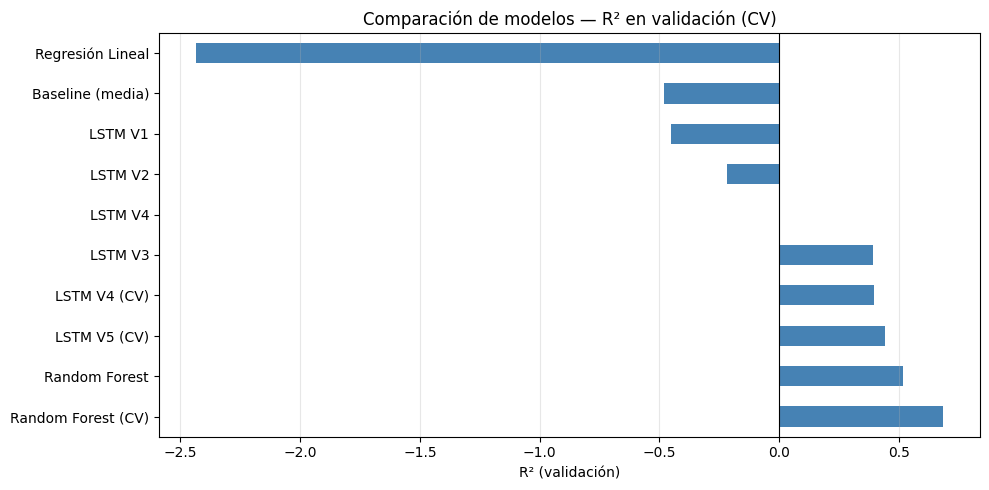

In [56]:
mae_log_mean = cv_lstm_v5_folds['MAE'].mean()
rmse_log_mean = cv_lstm_v5_folds['RMSE'].mean()
r2_mean = cv_lstm_v5_folds['R2'].mean()

# Convertir MAE y RMSE de log a metros (aproximado)
mae_metros = np.expm1(mae_log_mean)
rmse_metros = np.expm1(rmse_log_mean)

# Guardar en results (para la tabla de comparación)
results["LSTM V5 (CV)"] = {
    "MAE": mae_metros,
    "RMSE": rmse_metros,
    "R2": r2_mean   # El R² se mantiene en log porque no se puede transformar directamente
}

comparison = pd.DataFrame(results).T[["MAE", "RMSE", "R2"]].sort_values("R2", ascending=False)
comparison.columns = ["MAE (m)", "RMSE (m)", "R²"]
display(comparison.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
comparison["R²"].plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("R² (validación)")
ax.set_title("Comparación de modelos — R² en validación (CV)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Notas finales

- Los modelos marcados con **(CV)** usan la media de GroupKFold (5 folds),Random Forest,LSTM V4 y V5   son la estimación más
  confiable del desempeño real, dado el tamaño pequeño del dataset. Los demás usan un solo split de
  validación — pueden ser optimistas o pesimistas según qué vuelos cayeron ahí por azar.



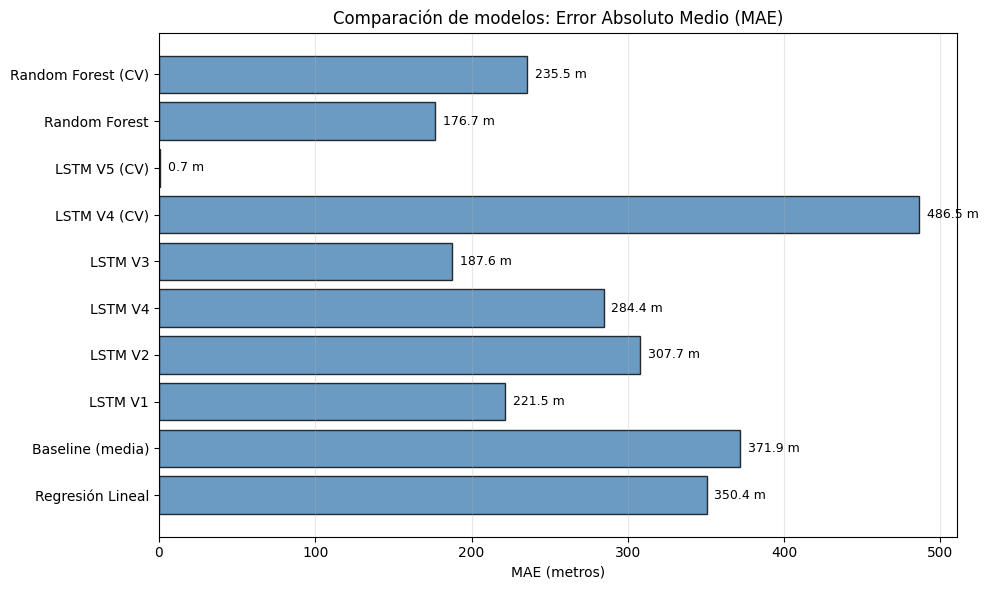

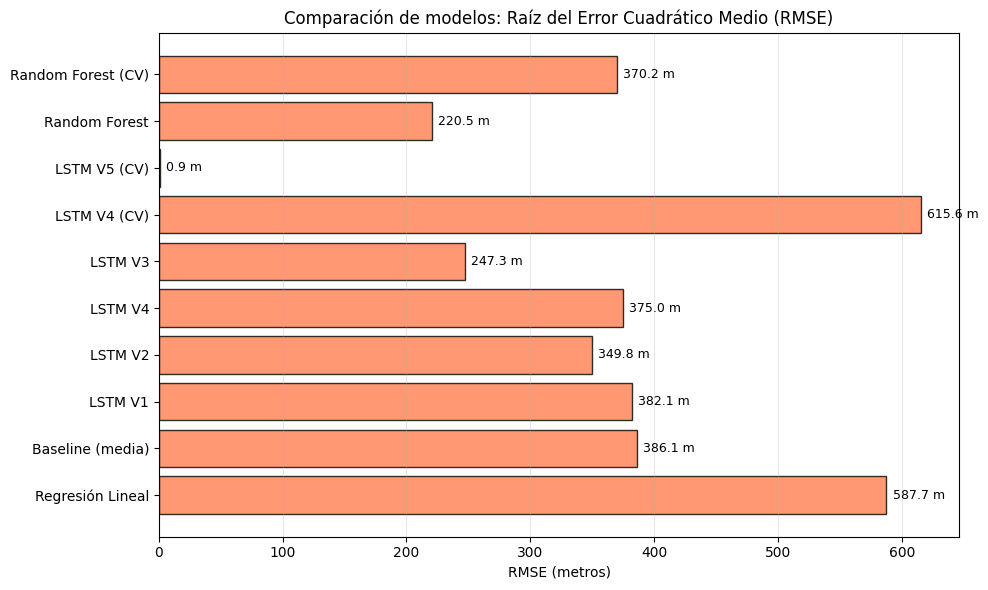


Tabla resumen de todos los modelos:


,Modelo,MAE (m),RMSE (m),R²
0,Random Forest (CV),235.5,370.2,0.683
1,Random Forest,176.7,220.5,0.517
2,LSTM V5 (CV),0.7,0.9,0.443
3,LSTM V4 (CV),486.5,615.6,0.396
4,LSTM V3,187.6,247.3,0.392
5,LSTM V4,284.4,375.0,0.000
6,LSTM V2,307.7,349.8,-0.217
7,LSTM V1,221.5,382.1,-0.452
8,Baseline (media),371.9,386.1,-0.482
9,Regresión Lineal,350.4,587.7,-2.434


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


df_all = pd.DataFrame(results).T

cv_models = [idx for idx in df_all.index if "CV" in idx or "(CV)" in idx]

rows = []
for model_name in df_all.index:
    row = df_all.loc[model_name]
    # Si tiene columnas MAE_std, RMSE_std, R2_std (de summarize_cv)
    if "MAE_std" in row:
        mae = row["MAE"]
        mae_std = row["MAE_std"]
        rmse = row["RMSE"]
        rmse_std = row["RMSE_std"]
        r2 = row["R2"]
        r2_std = row["R2_std"]
        has_std = True
    else:
        mae = row["MAE"]
        mae_std = np.nan
        rmse = row["RMSE"]
        rmse_std = np.nan
        r2 = row["R2"]
        r2_std = np.nan
        has_std = False
    
    rows.append({
        "Modelo": model_name,
        "MAE": mae,
        "MAE_std": mae_std,
        "RMSE": rmse,
        "RMSE_std": rmse_std,
        "R2": r2,
        "R2_std": r2_std,
        "has_std": has_std
    })

df_plot = pd.DataFrame(rows)

# Ordenar por R² descendente (mejor modelo primero)
df_plot = df_plot.sort_values("R2", ascending=False).reset_index(drop=True)
# 2. Gráfica de MAE
fig, ax = plt.subplots(figsize=(10, 6))

for i, row in df_plot.iterrows():
    color = 'steelblue'
    if row['has_std']:
        ax.barh(row['Modelo'], row['MAE'], xerr=row['MAE_std'], 
                color=color, edgecolor='black', capsize=5, 
                alpha=0.8, label='_nolegend_')
        label = f"{row['MAE']:.1f} ± {row['MAE_std']:.1f} m"
    else:
        ax.barh(row['Modelo'], row['MAE'], color=color, edgecolor='black', alpha=0.8)
        label = f"{row['MAE']:.1f} m"
    
    ax.text(row['MAE'] + 5, i, label, va='center', fontsize=9)

ax.set_xlabel('MAE (metros)')
ax.set_title('Comparación de modelos: Error Absoluto Medio (MAE)')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()  # Para que el mejor modelo esté arriba

plt.tight_layout()
plt.show()

# 3. Gráfica de RMSE
fig, ax = plt.subplots(figsize=(10, 6))

for i, row in df_plot.iterrows():
    color = 'coral'
    if row['has_std']:
        ax.barh(row['Modelo'], row['RMSE'], xerr=row['RMSE_std'],
                color=color, edgecolor='black', capsize=5,
                alpha=0.8, label='_nolegend_')
        label = f"{row['RMSE']:.1f} ± {row['RMSE_std']:.1f} m"
    else:
        ax.barh(row['Modelo'], row['RMSE'], color=color, edgecolor='black', alpha=0.8)
        label = f"{row['RMSE']:.1f} m"
    
    ax.text(row['RMSE'] + 5, i, label, va='center', fontsize=9)

ax.set_xlabel('RMSE (metros)')
ax.set_title('Comparación de modelos: Raíz del Error Cuadrático Medio (RMSE)')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()
# Mostrar una tabla bonita con valores y desviaciones
display_df = df_plot[['Modelo', 'MAE', 'MAE_std', 'RMSE', 'RMSE_std', 'R2', 'R2_std']].copy()
display_df['MAE'] = display_df.apply(lambda r: f"{r['MAE']:.1f} ± {r['MAE_std']:.1f}" if pd.notna(r['MAE_std']) else f"{r['MAE']:.1f}", axis=1)
display_df['RMSE'] = display_df.apply(lambda r: f"{r['RMSE']:.1f} ± {r['RMSE_std']:.1f}" if pd.notna(r['RMSE_std']) else f"{r['RMSE']:.1f}", axis=1)
display_df['R2'] = display_df.apply(lambda r: f"{r['R2']:.3f} ± {r['R2_std']:.3f}" if pd.notna(r['R2_std']) else f"{r['R2']:.3f}", axis=1)
display_df = display_df[['Modelo', 'MAE', 'RMSE', 'R2']]
display_df.columns = ['Modelo', 'MAE (m)', 'RMSE (m)', 'R²']

print("\nTabla resumen de todos los modelos:")
display(display_df)